# Trabajo final Análisis de Datos
## Dataset: <i>"Diabetes 130-US Hospitals for Years 1999-2008"</i>

### Participantes:
- Berdaguer, Carlos Agustín
- Campi, Lucas
- Chutchurru, Fernando
- Pinzón, Jaime
- Souto, Matías Agustín

---

# Conjunto de datos

Cada instancia del dataset representa los registros de pacientes hospitalizados diagnosticados con diabetes. El conjunto de datos representa diez años (1999-2008) de atención clínica en 130 hospitales y redes integradas de atención médica de EE. UU. Incluye más de 50 variables que relacionadas a los pacientes y los hospitales. Se extrajo información de la base de datos para los encuentros que cumplían los siguientes criterios:

1. Es un encuentro de hospitalización (ingreso hospitalario).

2. Es un encuentro relacionado con la diabetes, es decir, uno en el que se registró algún tipo de diabetes en el sistema como diagnóstico.
3. La duración de la estancia fue de al menos 1 día y como máximo 14 días.
4. Se realizaron análisis de laboratorio durante la consulta.
5. Se administraron medicamentos durante la consulta.

Los datos incluyen atributos como número de paciente, raza, sexo, edad, tipo de ingreso, tiempo de hospitalización, especialidad del médico responsable del ingreso, número de análisis de laboratorio realizados, resultado de la prueba de HbA1c, diagnóstico, número de medicamentos, medicamentos para la diabetes, número de consultas ambulatorias, hospitalizaciones y visitas a urgencias en el año anterior a la hospitalización, etc. La descripción extendida y su traducción se puede encontrar en [la notebook adjunta](tablaDeVariablesExtendida.ipynb)

Por otro lado, se adjunta también el archivo [IDS_mapping.csv](data/IDS_mapping.csv). Éste es un archivo que contiene los mapeos de ids a descripciones de tres variables:
- Admission type
- Admission source
- Discharge disposition

Lamentablemente, el archivo original toma la forma de tres csvs concatenados. Lo que lo hace imposible de importar en ese estado. Para ello, se crea una función auxiliar que los corta en distintos csvs:

In [127]:
from utils.auxiliares import read_multi_csv
import io

for file,data in read_multi_csv('data/IDS_mapping.csv').items():
    file_path = f"data/{file}_mapping.csv"
    data.to_csv(file_path, index=False)
    print(f"Mapping de {file} guardado en {file_path}")

Mapping de admission_type_id guardado en data/admission_type_id_mapping.csv
Mapping de discharge_disposition_id guardado en data/discharge_disposition_id_mapping.csv
Mapping de admission_source_id guardado en data/admission_source_id_mapping.csv


---

## Carga de datos

Una vez obtenidos los mappings, importamos la data original, los mappings y, via `pd.merge`, agregamos las descripciones de los mappings a la data

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype
import numpy as np
from graficadores.histogramas import plot_histograma
from sklearn.model_selection import train_test_split

In [129]:
data = pd.read_csv("./data/diabetic_data.csv")
admission_types_mapping = pd.read_csv("./data/admission_type_id_mapping.csv")
admission_source_mapping = pd.read_csv("./data/admission_source_id_mapping.csv")
discharge_disposition_mapping = pd.read_csv("./data/discharge_disposition_id_mapping.csv")

In [130]:
data = pd.merge(data,admission_types_mapping,how="left", on="admission_type_id")
data = pd.merge(data,admission_source_mapping,how="left", on="admission_source_id")
data = pd.merge(data,discharge_disposition_mapping,how="left", on="discharge_disposition_id")
data.head(2)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type_description,admission_source_description,discharge_disposition_description
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,NO,NaN,Physician Referral,Not Mapped
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,No,No,No,Ch,Yes,>30,Emergency,Emergency Room,Discharged to home


---

# Análisis general de datos

## Análisis estructural


### Cantidad de observaciones

In [131]:
data.shape

(101766, 53)

In [132]:
data.dtypes.value_counts()

object    40
int64     13
Name: count, dtype: int64

El dataset tiene 101.766 registros en 53 variables de las cuales 40 son categóricas y 13 son numéricas

### Recategorización básica

Las variables `encounter_id, patient_nbr, admission_type_id, discharge_disposition_id, admission_source_id` figuran como numéricas pero en realidad son ids o códigos. Se reemplazará por ese tipo de datos

In [133]:
data[["encounter_id", "patient_nbr"]] = data[["encounter_id", "patient_nbr"]].astype("string")
data[["admission_type_id", "discharge_disposition_id", "admission_source_id"]] = data[["admission_type_id", "discharge_disposition_id", "admission_source_id"]].astype("category")

In [134]:
data.dtypes.value_counts()

object      40
int64        8
string       2
category     1
category     1
category     1
Name: count, dtype: int64

El dataset contiene ahora 53 variables de las cuales 45 son categóricas y 8 son numéricas

### Cantidad de nulos

In [135]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   encounter_id                       101766 non-null  string  
 1   patient_nbr                        101766 non-null  string  
 2   race                               101766 non-null  object  
 3   gender                             101766 non-null  object  
 4   age                                101766 non-null  object  
 5   weight                             101766 non-null  object  
 6   admission_type_id                  101766 non-null  category
 7   discharge_disposition_id           101766 non-null  category
 8   admission_source_id                101766 non-null  category
 9   time_in_hospital                   101766 non-null  int64   
 10  payer_code                         101766 non-null  object  
 11  medical_specialty         

La mayoría de las variables tienen todos los datos excepto las siguientes:

In [136]:
data.loc[:, data.isna().any()].columns

Index(['max_glu_serum', 'A1Cresult', 'admission_type_description',
       'admission_source_description', 'discharge_disposition_description'],
      dtype='object')

#### `max_glu_serum`

Según la tabla, el valor es vacío si no se midió. Así que es un ausente <b>estructural</b>

#### `A1Cresult`

Ídem anterior, el valor nulo implica que no se realizó ese test. Así que es un ausente <b>estructural</b>

#### `admission_type_description`, `admission_source_description`, y `discharge_disposition_description`

En todos esos casos, existe un id cuyo valor es `NULL` en el csv original. Al hacer la conversión a dataframe, directamente se castea a `np.nan`. Por lo tanto, también son casos de ausente <b>estructural</b>

En conclusión, todos los valores faltantes son esperables o interpretables. Además, como todas las variables son categóricas, podemos imputarles directamente el valor `"desconocido"` y ya no quedarán variables sin valores

In [137]:
data.loc[:, data.isna().any()] = data.loc[:, data.isna().any()].fillna("desconocido")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   encounter_id                       101766 non-null  string  
 1   patient_nbr                        101766 non-null  string  
 2   race                               101766 non-null  object  
 3   gender                             101766 non-null  object  
 4   age                                101766 non-null  object  
 5   weight                             101766 non-null  object  
 6   admission_type_id                  101766 non-null  category
 7   discharge_disposition_id           101766 non-null  category
 8   admission_source_id                101766 non-null  category
 9   time_in_hospital                   101766 non-null  int64   
 10  payer_code                         101766 non-null  object  
 11  medical_specialty         

In [138]:
data.isna().sum().sum()

0

Sin embargo, al consultar la tabla, menciona que hay otras variables que tienen datos faltantes que no figuran como `np.nan`:
- `race`
- `weight`
- `payer_code`
- `medical_specialty`
- `diag_3`

Veamos en qué consiste


In [139]:
inconsistent_columns = ["race","weight","payer_code","medical_specialty","diag_3"]
data[inconsistent_columns]

,race,weight,payer_code,medical_specialty,diag_3
0,Caucasian,?,?,Pediatrics-Endocrinology,?
1,Caucasian,?,?,?,255
2,AfricanAmerican,?,?,?,V27
3,Caucasian,?,?,?,403
4,Caucasian,?,?,?,250
...,...,...,...,...,...
101761,AfricanAmerican,?,MC,?,458
101762,AfricanAmerican,?,MC,?,787
101763,Caucasian,?,MC,?,296
101764,Caucasian,?,MC,Surgery-General,998


El `?` representa un valor desconocido. Pensemos para cada una de las variables una heurística para cada una. Para analizar si el valor falta recurrentemente en todas las columnas, se usa `missingno`

<Axes: >

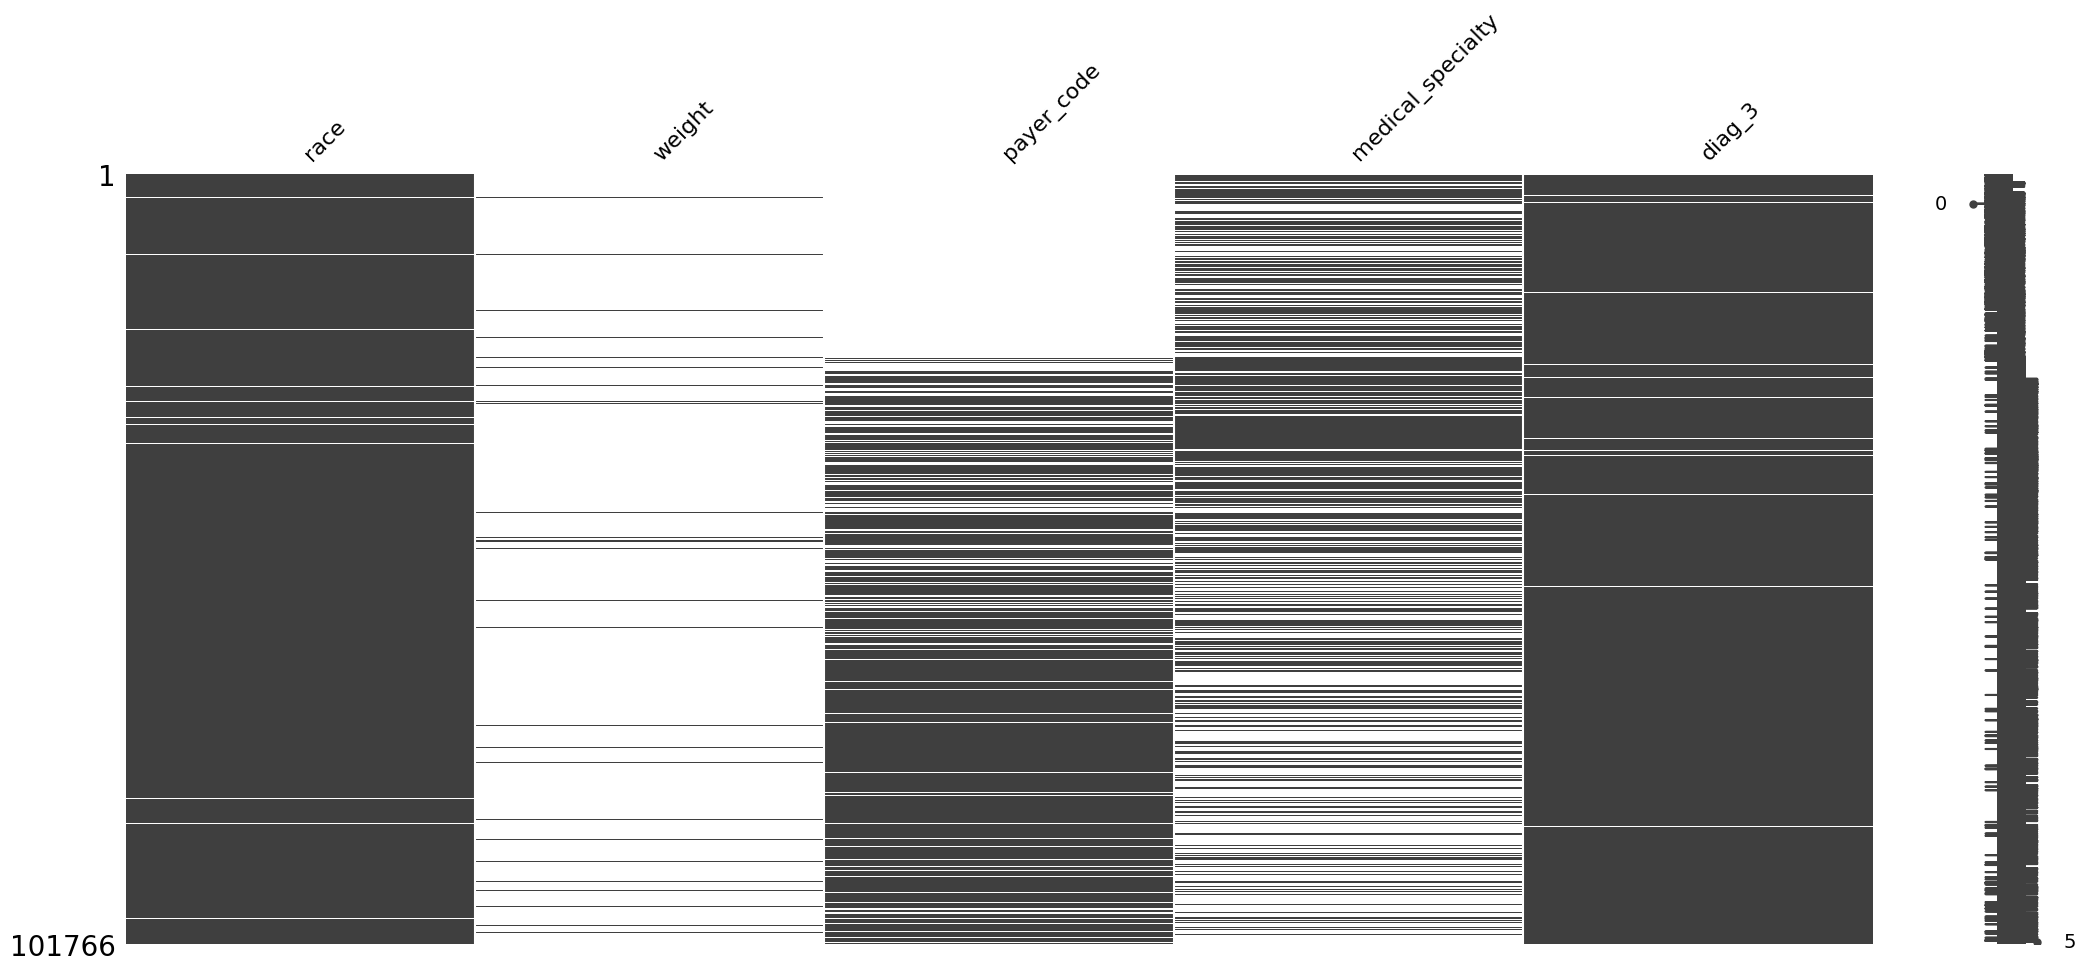

In [140]:
import missingno as msno
inconsistent_missings = data.replace("?",np.nan)
msno.matrix(inconsistent_missings[inconsistent_columns])

No hay un patrón evidente de horizontalidad en estas variables

#### `weight`

Es evidente es que la variable `weight` tiene demasiado pocos registros. Según el [paper del que citamos las tablas](https://onlinelibrary.wiley.com/doi/10.1155/2014/781670) la ausencia masiva de `weight` puede estar relacionada a un tema de legislación de EE.UU que no obligaba a capturar de forma estructurada este valor. Así que decidimos eliminar esta variable del análisis

In [141]:
data = data.drop("weight", axis=1)


#### `race`

In [142]:
data["race"].value_counts(normalize=True)

race
Caucasian          0.747784
AfricanAmerican    0.188766
?                  0.022336
Hispanic           0.020017
Other              0.014799
Asian              0.006299
Name: proportion, dtype: float64

Teniendo el campo `patient_nbr` podemos buscar si hay otros registros de pacientes sin el campo `race` para los cuales sí se les completo el campo `race`.

In [143]:
from utils.auxiliares import recover_feature

data = recover_feature(data, "race", "patient_nbr")

data["race"].value_counts(normalize=True)

race
Caucasian          0.748904
AfricanAmerican    0.188894
?                  0.020921
Hispanic           0.020115
Other              0.014867
Asian              0.006299
Name: proportion, dtype: float64

A penas se recuperó un 0,1% con este intento. Siendo sólamente el 2% el faltante de los datos, podrían descartarse o imputarse como `Other` ya que se tiene esa categoría disponible y representa muy pocos registros del dataset; pero a los fines del trabajo vamos a buscar alguna relación con el feature `age` para ver si se puede cosiderar **MAR**.

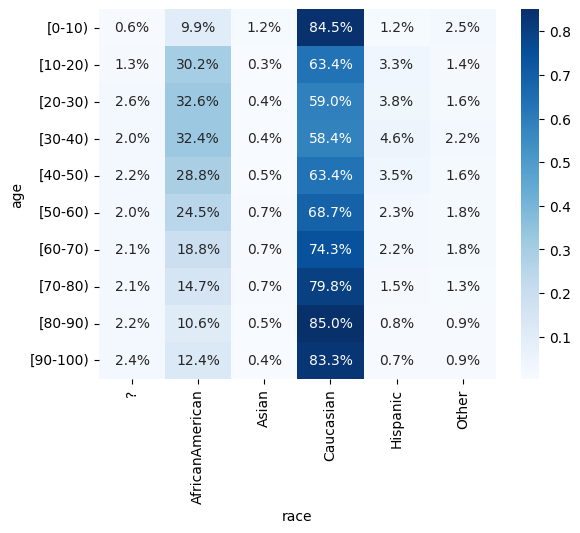

In [144]:
cross_tab = pd.crosstab(data["age"], data["race"], normalize="index")
sns.heatmap(cross_tab, annot=True, fmt=".1%", cmap="Blues", vmax=cross_tab.values.max())
plt.show()

El porcentaje de faltantes es muy cercano entre todos los rangos etarios, por lo que se ya puede considerar **MCAR** e imputar con el valor `Other`.

In [145]:
data["race"] = data["race"].replace("?","Other")
data["race"].value_counts(normalize=True)

race
Caucasian          0.748904
AfricanAmerican    0.188894
Other              0.035788
Hispanic           0.020115
Asian              0.006299
Name: proportion, dtype: float64

#### `medical_specialty`

In [146]:
(data["medical_specialty"].apply(lambda x: x if x=="?" else "Conocido")).value_counts()

medical_specialty
Conocido    51817
?           49949
Name: count, dtype: int64

La especialidad médica no fue declarada en cerca de la mitad de los casos. Si queremos preservarla en el análisis, tenemos otra opción más que dejarla como está. Se reemplazará por `"Unknown"` que es un valor disponible entre los existentes.

In [147]:
data["medical_specialty"] = data["medical_specialty"].replace("?","Unknown")

#### `payer_code`

In [148]:
(data["payer_code"].apply(lambda x: x if x=="?" else "Conocido")).value_counts()

payer_code
Conocido    61510
?           40256
Name: count, dtype: int64

También casi la mitad de los datos no cuentan con un tipo de pago. Intentamos buscar una relación con pacientes de poca edad para ver si la falta de valor es estructural.

In [149]:
from utils.auxiliares import group_by_condition

group_by_condition(data, "age", "payer_code", lambda x: x == "?")

,age,percentage_of_payer_code
0,[0-10),91.304348
1,[10-20),67.004342
2,[20-30),36.934218
3,[30-40),44.344371
4,[40-50),42.839442
5,[50-60),42.350487
6,[60-70),39.549882
7,[70-80),40.375173
8,[80-90),33.098796
9,[90-100),28.428213


Si bien gran parte de los menores figuran sin tipo de pago, el resto de los rangos etarios también presentan un porcentaje considerable de valores nulos para el feature. No es posible asociarlo. Aún no sabemos si vamos a utilizar esta variable en algún tipo de análisis. Así que la mantendremos como `"Unknown"`

In [150]:
data["payer_code"] = data["payer_code"].replace("?","Unknown")

#### `diag_3`

In [151]:
(data["diag_3"].apply(lambda x: x if x=="?" else "Conocido")).value_counts(normalize=True)

diag_3
Conocido    0.986017
?           0.013983
Name: proportion, dtype: float64

Solo falta alrededor del 1% de los diagnósticos terciarios. Como la documentación dice que es un "diagnóstico secundario adicional", veamos si `diag_2` es consistente

In [152]:
(data["diag_2"].apply(lambda x: x if x=="?" else "Conocido")).value_counts(normalize=True)

diag_2
Conocido    0.996482
?           0.003518
Name: proportion, dtype: float64

`diag_2` también tiene una cantidad marginal de `?`. Como es "diagnóstico secundario" veamos si el `diag_1` es consistente

In [153]:
(data["diag_1"].apply(lambda x: x if x=="?" else "Conocido")).value_counts(normalize=True)

diag_1
Conocido    0.999794
?           0.000206
Name: proportion, dtype: float64

También pasa lo mismo pero a un nivel ínfimo. El abordaje para esto será imputarlos en cascada `diag_1 > diag_2 > diag_3`. Para eso, se reemplazan por `np.nan` y se hace fillna con su predecesor

In [154]:
data["diag_1"].replace("?", "None")
data[["diag_2","diag_3"]] = data[["diag_2","diag_3"]].replace("?", np.nan)
data['diag_2'] = data['diag_2'].fillna(data['diag_1'])
data['diag_3'] = data['diag_3'].fillna(data['diag_2'])

### Forma final de data

In [155]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 52 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   encounter_id                       101766 non-null  string  
 1   patient_nbr                        101766 non-null  string  
 2   race                               101766 non-null  object  
 3   gender                             101766 non-null  object  
 4   age                                101766 non-null  object  
 5   admission_type_id                  101766 non-null  category
 6   discharge_disposition_id           101766 non-null  category
 7   admission_source_id                101766 non-null  category
 8   time_in_hospital                   101766 non-null  int64   
 9   payer_code                         101766 non-null  object  
 10  medical_specialty                  101766 non-null  object  
 11  num_lab_procedures        

---

## Split del set de datos
Dado que tenemos como objetivo predecir el `time_in_hospital` de un paciente, haremos la separación de datos en features y target.

In [156]:
target   = 'time_in_hospital'

X = data.drop(columns=[target])
y = data[target]

print(f"Dimensión de X: {X.shape}")
print(f"Dimensión de y: {y.shape}")

Dimensión de X: (101766, 51)
Dimensión de y: (101766,)


In [157]:
X.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,payer_code,medical_specialty,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type_description,admission_source_description,discharge_disposition_description
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,Unknown,Pediatrics-Endocrinology,...,No,No,No,No,No,No,NO,desconocido,Physician Referral,Not Mapped
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,Unknown,Unknown,...,No,No,No,No,Ch,Yes,>30,Emergency,Emergency Room,Discharged to home
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,Unknown,Unknown,...,No,No,No,No,No,Yes,NO,Emergency,Emergency Room,Discharged to home
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,Unknown,Unknown,...,No,No,No,No,Ch,Yes,NO,Emergency,Emergency Room,Discharged to home
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,Unknown,Unknown,...,No,No,No,No,Ch,Yes,NO,Emergency,Emergency Room,Discharged to home


In [158]:
y.head()

0    1
1    3
2    2
3    2
4    1
Name: time_in_hospital, dtype: int64

Procedemos al split de dataset. En particular, observaremos las ocurrencias cuando hacemos un `stratify` al split o no.

In [159]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    shuffle = True,
    stratify = None
)

X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y
)

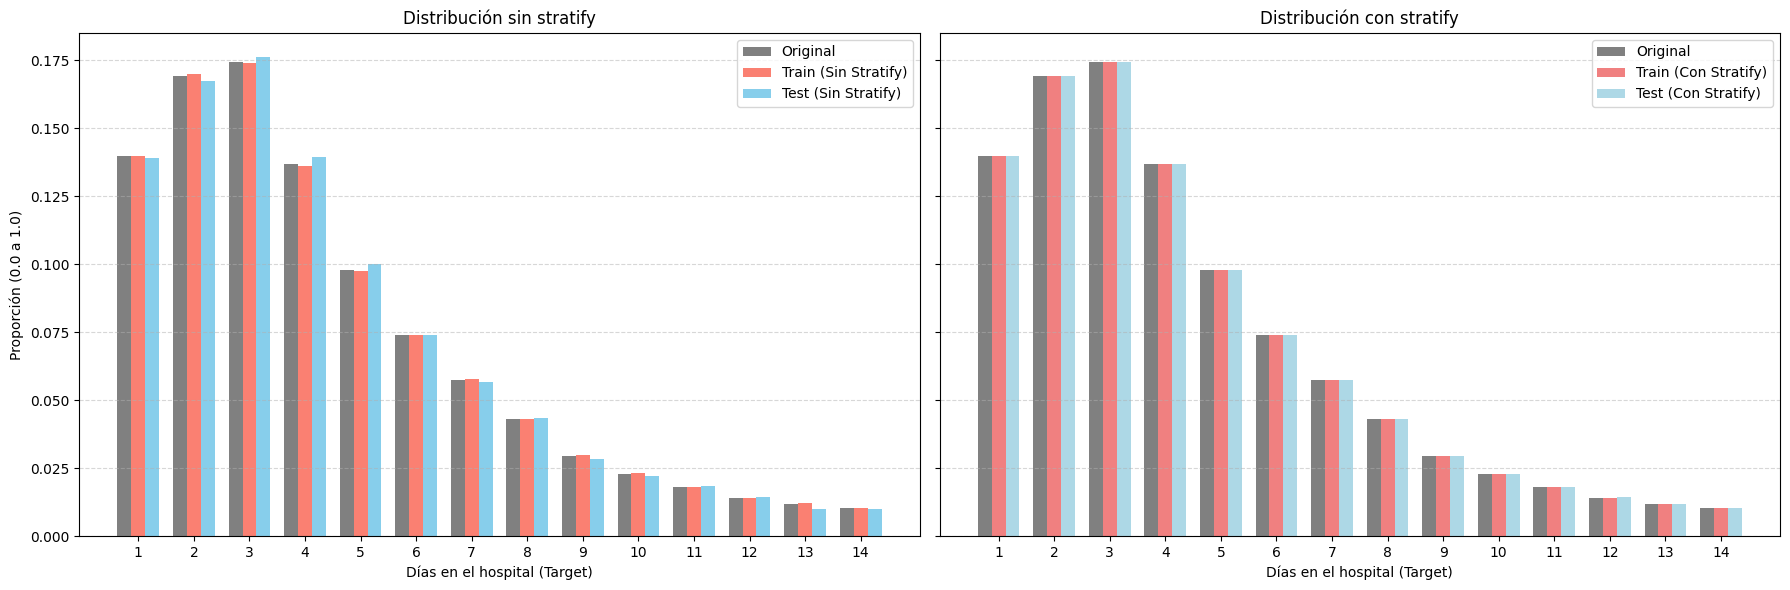

In [160]:
prop_original = pd.Series(y).value_counts(normalize=True).sort_index()
prop_train_without_strat = pd.Series(y_train).value_counts(normalize=True).sort_index()
prop_train_with_strat = pd.Series(y_train_strat).value_counts(normalize=True).sort_index()
prop_test_without_strat = pd.Series(y_test).value_counts(normalize=True).sort_index()
prop_test_with_strat = pd.Series(y_test_strat).value_counts(normalize=True).sort_index()

x_indices = prop_original.index
width = 0.1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
width = 0.25

ax1.bar(
    x_indices - width,
    prop_original.values,
    width=width,
    label='Original',
    color='gray',
)
ax1.bar(
    x_indices,
    prop_train_without_strat.values,
    width=width,
    label='Train (Sin Stratify)',
    color='salmon',
)
ax1.bar(
    x_indices + width,
    prop_test_without_strat.values,
    width=width,
    label='Test (Sin Stratify)',
    color='skyblue',
)

ax1.set_title('Distribución sin stratify')
ax1.set_xlabel('Días en el hospital (Target)')
ax1.set_ylabel('Proporción (0.0 a 1.0)')
ax1.set_xticks(x_indices)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax2.bar(
    x_indices - width,
    prop_original.values,
    width=width,
    label='Original',
    color='gray',
)
ax2.bar(
    x_indices,
    prop_train_with_strat.values,
    width=width,
    label='Train (Con Stratify)',
    color='lightcoral',
)
ax2.bar(
    x_indices + width,
    prop_test_with_strat.values,
    width=width,
    label='Test (Con Stratify)',
    color='lightblue',
)

ax2.set_title('Distribución con stratify')
ax2.set_xlabel('Días en el hospital (Target)')
ax2.set_xticks(x_indices)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Como el dataset tiene una gran cantidad de observaciones, podemos ver que, en el split, se mantiene la proporción de observaciones tanto para train como para test. A fines prácticos, vamos a utilizar `stratify` que nos da un poco más de equilibrio en los datos.

Usaremos el set de entrenamiento para analizar la relación entre las variables.

---

## Análisis de outliers


### Variables numéricas

In [161]:
X_train_strat.describe()

,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,81412.000000,81412.000000,81412.000000,81412.000000,81412.000000,81412.000000,81412.000000
mean,43.123913,1.339667,16.033988,0.368852,0.194099,0.635742,7.422677
std,19.642855,1.709067,8.117912,1.257310,0.903541,1.259624,1.934908
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,32.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [162]:
y_train_strat.describe().to_frame()

,time_in_hospital
count,81412.000000
mean,4.396010
std,2.985145
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,14.000000


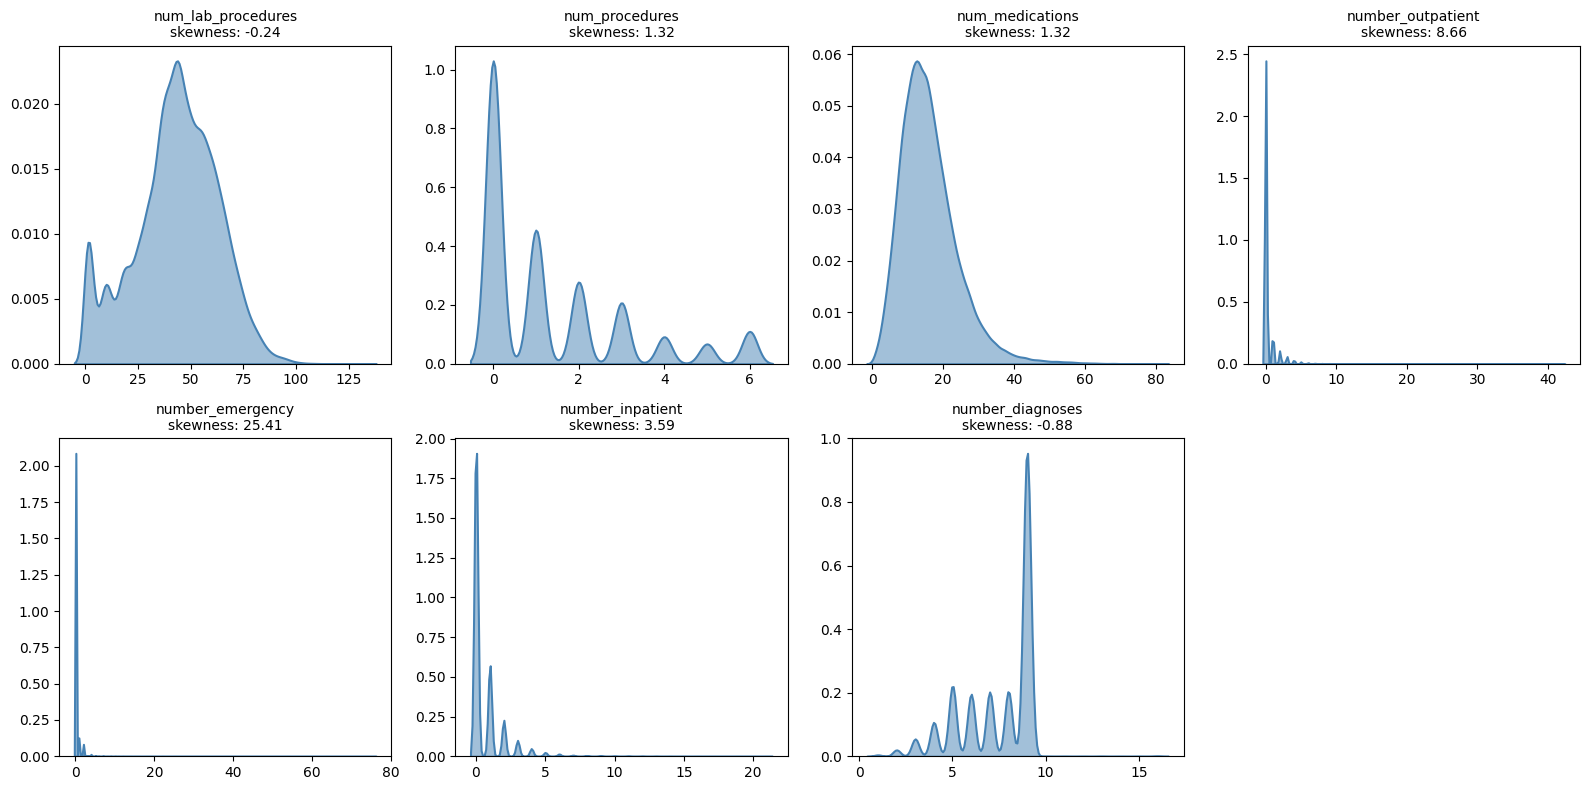

In [163]:
columnas_numericas = X_train_strat.describe().columns

def plot_skewness(columns):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i, var in enumerate(columns):
        ax = axes[i]
        
        skew = X_train_strat[var].skew()
        
        sns.kdeplot(
            X_train_strat[var].dropna(),
            ax=ax,
            fill=True,
            color='steelblue',
            alpha=0.5,
            linewidth=1.5
        )
        
        ax.set_title(f'{var}\nskewness: {skew:.2f}', fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('')

    # Ocultar el subplot vacío (posición 8)
    axes[-1].set_visible(False)

    plt.tight_layout()
    plt.show()
plot_skewness(columnas_numericas)

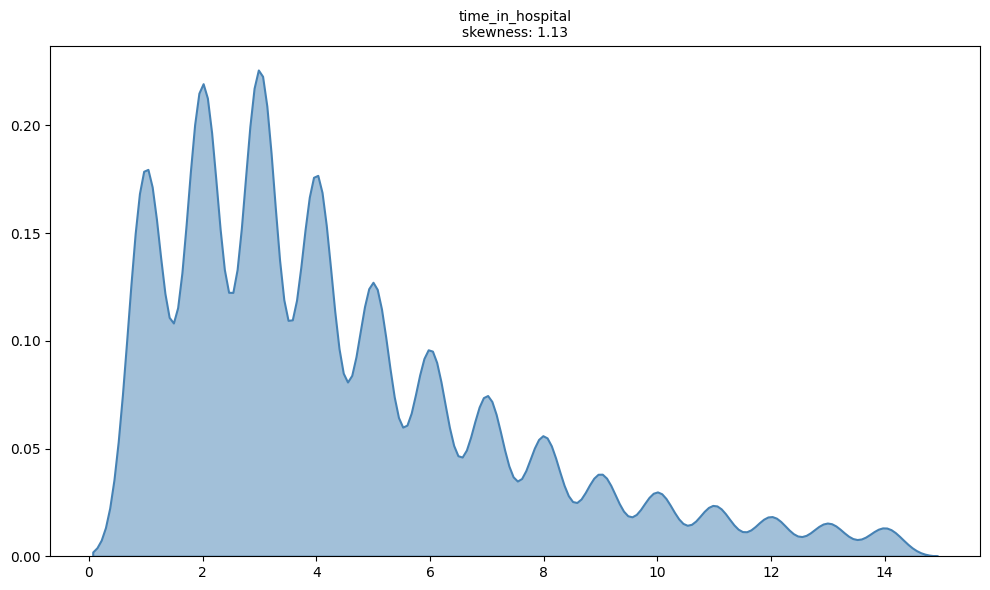

In [164]:
fig, ax = plt.subplots(figsize=(10,6))
skew = y_train_strat.skew()
        
sns.kdeplot(
    y_train_strat.dropna(),
    ax=ax,
    fill=True,
    color='steelblue',
    alpha=0.5,
    linewidth=1.5
)

ax.set_title(f'{y_train_strat.name}\nskewness: {skew:.2f}', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

Solamente `num_lab_procedures` tiene una forma que tiende a la simetría. El resto tiene asimetría de moderada a alta. Veamos una vez que filtremos los outliers

### Filtro de rango intercuartílico (IQR)

Vamos a aplicar el método del rango intercuartílico para analizar las variables numéricas que tenemos en el dataset

In [165]:
class IQR():
    def __init__(self, serie:pd.Series):
        self.serie = serie
        self.range = self.serie.quantile(0.75) - self.serie.quantile(0.25)
        self.upper = self.serie.quantile(0.75) + 1.5 * self.range
        self.lower = self.serie.quantile(0.25) - 1.5 * self.range

    def filter_outliers(self) -> pd.Series:
        return self.serie[self.serie.between(self.lower,self.upper)].copy()
    
    def get_outliers(self) -> pd.Series:
        return self.serie[~self.serie.between(self.lower,self.upper)].copy()
    
    def get_outliers_proportion(self):
        return round((self.get_outliers().size / self.serie.size) * 100,2)
    
    def get_ranges(self):
        values = self.__dict__.copy()
        del values["serie"]
        return values

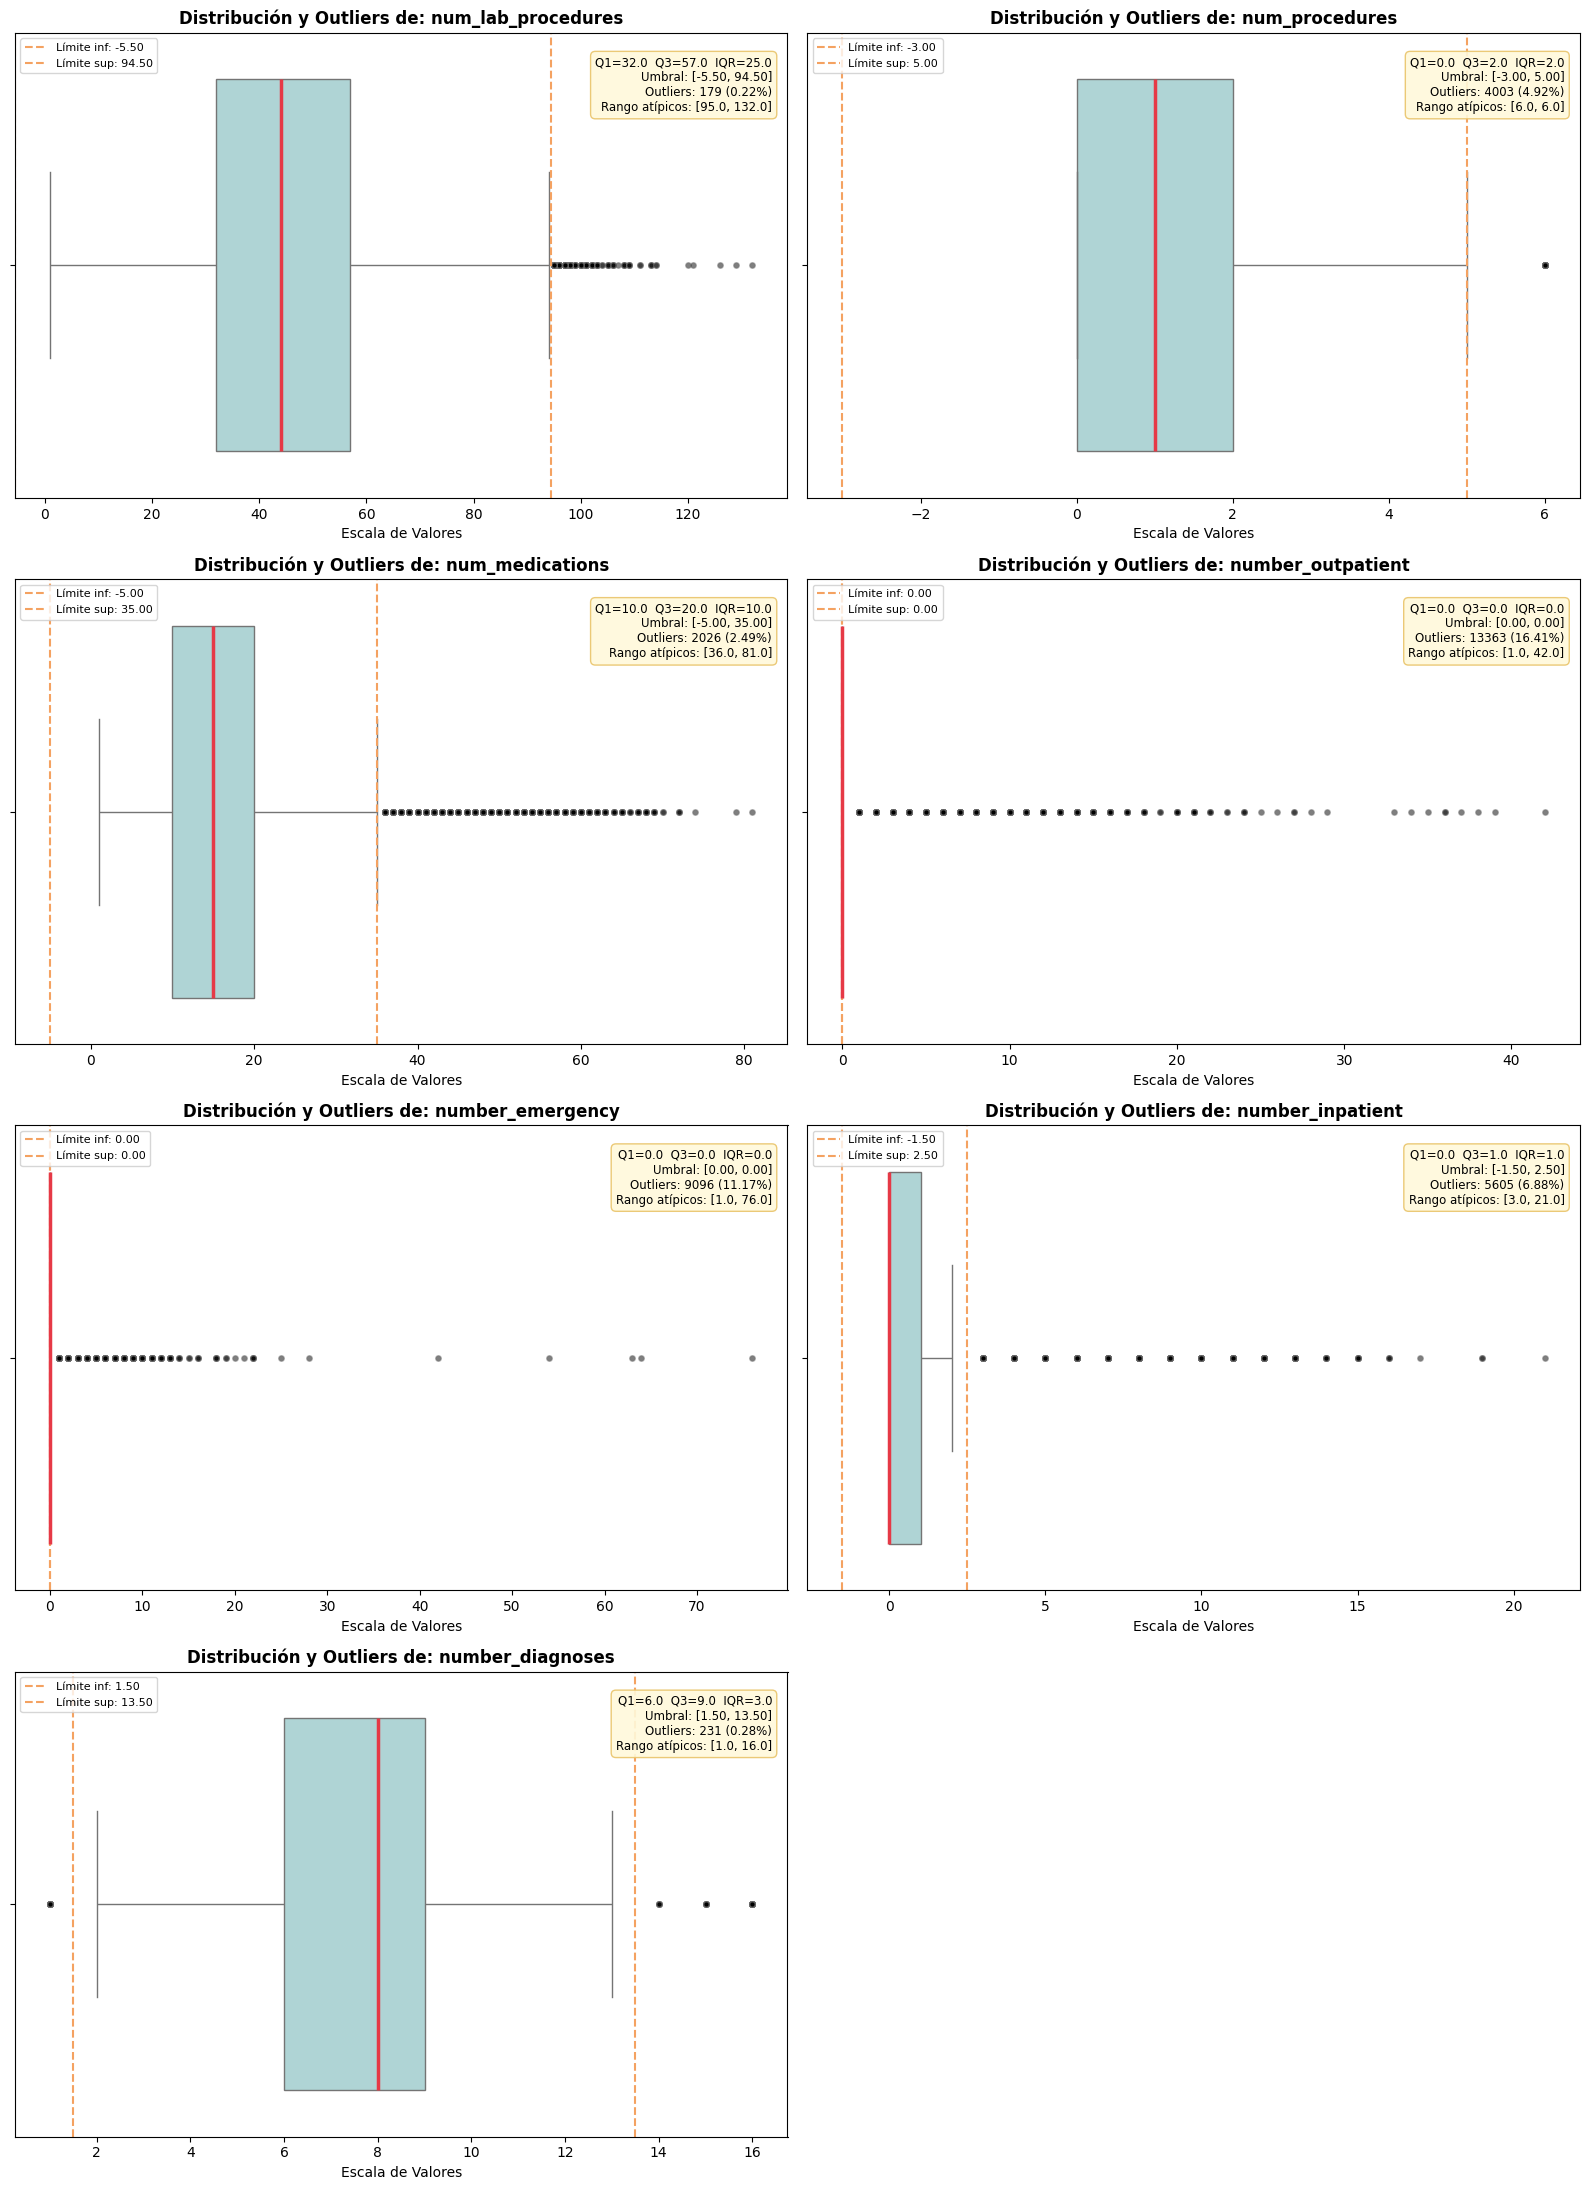

In [166]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    serie_datos = IQR(X_train_strat[col])
    ax = axes[i]
    
    sns.boxplot(
        x=serie_datos.serie, 
        ax=ax, 
        color='#a8dadc',
        medianprops=dict(color='#e63946', linewidth=2.5),
        flierprops=dict(markerfacecolor='black', marker='o', alpha=0.5, markersize=4)
    )
    
    ax.set_title(f"Distribución y Outliers de: {col}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Escala de Valores")
    
    # Líneas verticales de límites IQR
    ax.axvline(serie_datos.lower, color='#f4a261', linewidth=1.5, linestyle='--', label=f'Límite inf: {serie_datos.lower:.2f}')
    ax.axvline(serie_datos.upper, color='#f4a261', linewidth=1.5, linestyle='--', label=f'Límite sup: {serie_datos.upper:.2f}')
    
    # Texto con estadísticas dentro del gráfico
    stats_text = (
        f"Q1={serie_datos.serie.quantile(0.25):.1f}  Q3={serie_datos.serie.quantile(0.75):.1f}  IQR={serie_datos.range:.1f}\n"
        f"Umbral: [{serie_datos.lower:.2f}, {serie_datos.upper:.2f}]\n"
        f"Outliers: {len(serie_datos.get_outliers())} ({serie_datos.get_outliers_proportion()}%)"
    )
    if len(serie_datos.get_outliers()) > 0:
        stats_text += f"\nRango atípicos: [{serie_datos.get_outliers().min():.1f}, {serie_datos.get_outliers().max():.1f}]"
    
    ax.text(
        0.98, 0.95, stats_text,
        transform=ax.transAxes,
        fontsize=8.5,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff9db', edgecolor='#e9c46a', alpha=0.9)
    )
    
    ax.legend(fontsize=8, loc='upper left')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

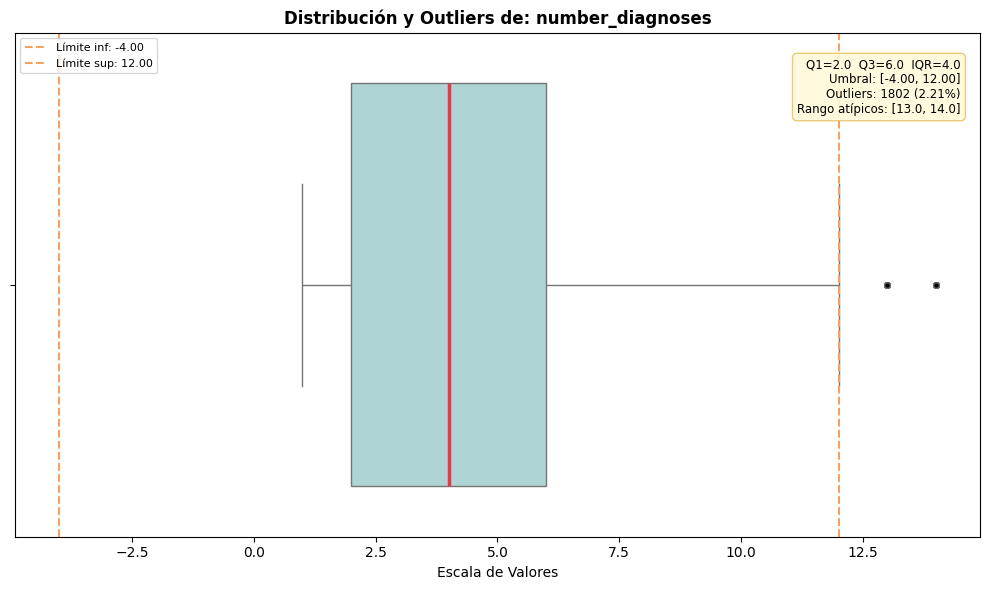

In [167]:
fig, ax = plt.subplots(figsize=(10,6))
serie_datos = IQR(y_train_strat)

sns.boxplot(
    x=serie_datos.serie, 
    ax=ax, 
    color='#a8dadc',
    medianprops=dict(color='#e63946', linewidth=2.5),
    flierprops=dict(markerfacecolor='black', marker='o', alpha=0.5, markersize=4)
)

ax.set_title(f"Distribución y Outliers de: {col}", fontsize=12, fontweight='bold')
ax.set_xlabel("Escala de Valores")

# Líneas verticales de límites IQR
ax.axvline(serie_datos.lower, color='#f4a261', linewidth=1.5, linestyle='--', label=f'Límite inf: {serie_datos.lower:.2f}')
ax.axvline(serie_datos.upper, color='#f4a261', linewidth=1.5, linestyle='--', label=f'Límite sup: {serie_datos.upper:.2f}')

# Texto con estadísticas dentro del gráfico
stats_text = (
    f"Q1={serie_datos.serie.quantile(0.25):.1f}  Q3={serie_datos.serie.quantile(0.75):.1f}  IQR={serie_datos.range:.1f}\n"
    f"Umbral: [{serie_datos.lower:.2f}, {serie_datos.upper:.2f}]\n"
    f"Outliers: {len(serie_datos.get_outliers())} ({serie_datos.get_outliers_proportion()}%)"
)
if len(serie_datos.get_outliers()) > 0:
    stats_text += f"\nRango atípicos: [{serie_datos.get_outliers().min():.1f}, {serie_datos.get_outliers().max():.1f}]"

ax.text(
    0.98, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=8.5,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff9db', edgecolor='#e9c46a', alpha=0.9)
)

ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

Eliminamos los valores atípicos

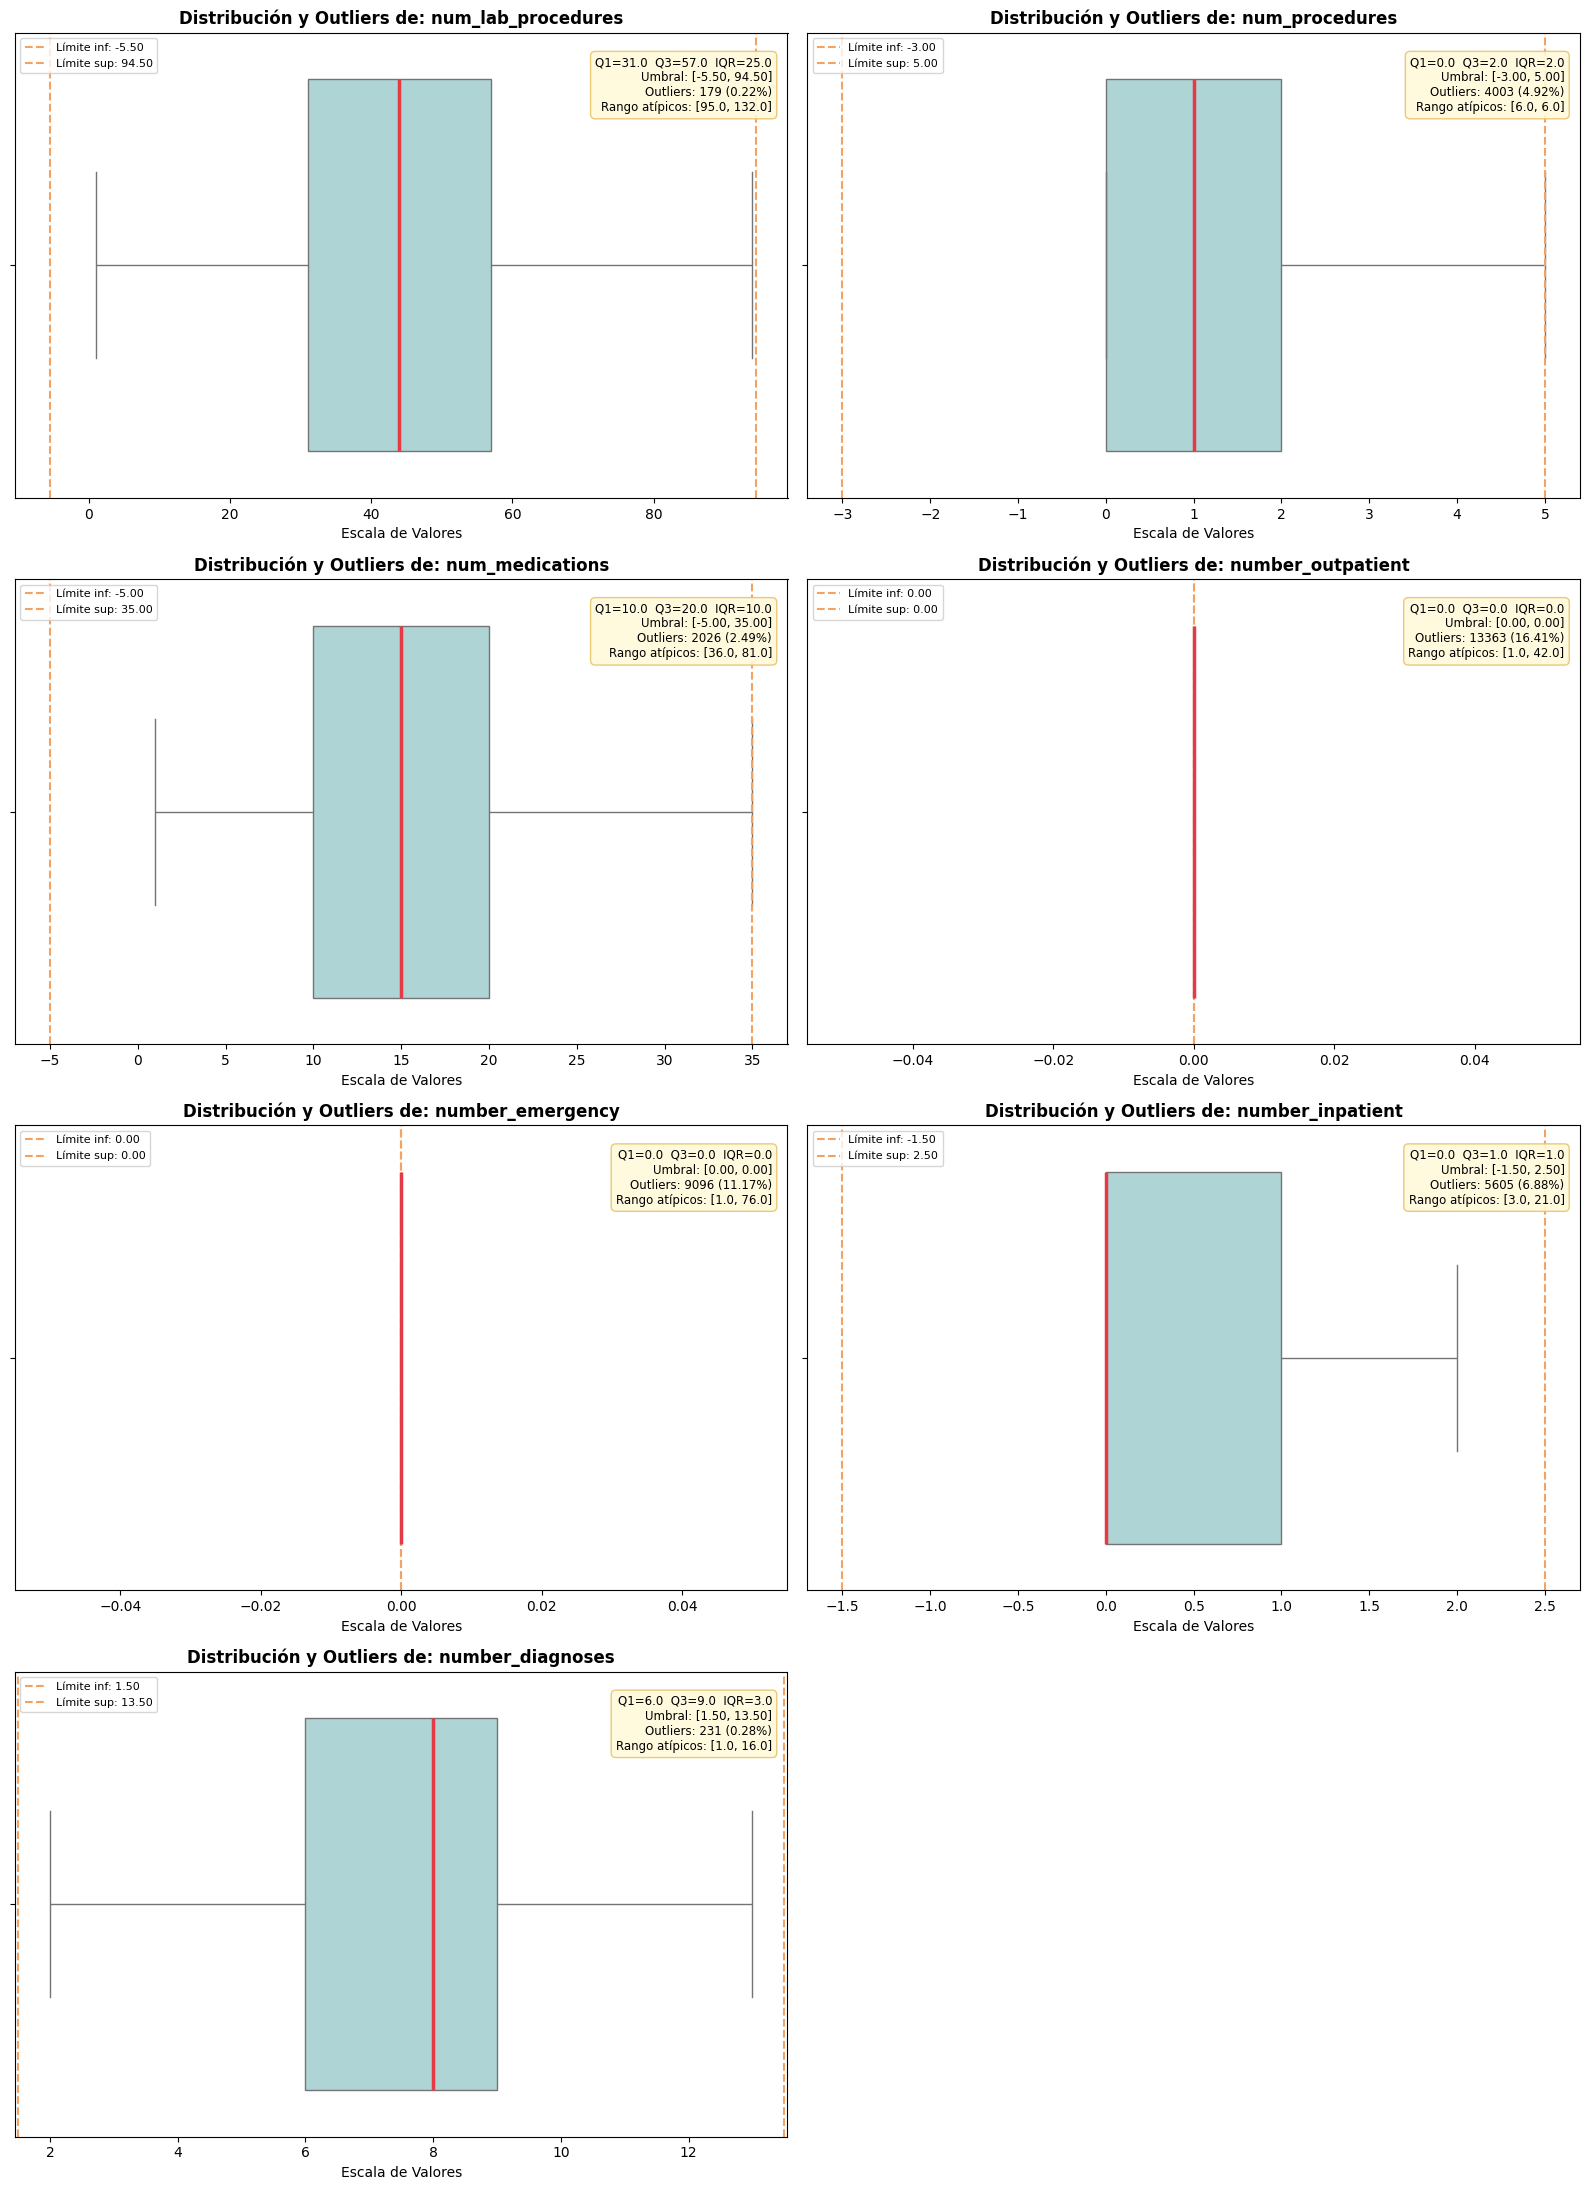

In [168]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    serie_datos = IQR(X_train_strat[col])
    ax = axes[i]
    
    sns.boxplot(
        x=serie_datos.filter_outliers(), 
        ax=ax, 
        color='#a8dadc',
        medianprops=dict(color='#e63946', linewidth=2.5),
        flierprops=dict(markerfacecolor='black', marker='o', alpha=0.5, markersize=4)
    )
    
    ax.set_title(f"Distribución y Outliers de: {col}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Escala de Valores")
    
    # Líneas verticales de límites IQR
    ax.axvline(serie_datos.lower, color='#f4a261', linewidth=1.5, linestyle='--', label=f'Límite inf: {serie_datos.lower:.2f}')
    ax.axvline(serie_datos.upper, color='#f4a261', linewidth=1.5, linestyle='--', label=f'Límite sup: {serie_datos.upper:.2f}')
    
    # Texto con estadísticas dentro del gráfico
    stats_text = (
        f"Q1={serie_datos.filter_outliers().quantile(0.25):.1f}  Q3={serie_datos.filter_outliers().quantile(0.75):.1f}  IQR={serie_datos.range:.1f}\n"
        f"Umbral: [{serie_datos.lower:.2f}, {serie_datos.upper:.2f}]\n"
        f"Outliers: {len(serie_datos.get_outliers())} ({serie_datos.get_outliers_proportion()}%)"
    )
    if len(serie_datos.get_outliers()) > 0:
        stats_text += f"\nRango atípicos: [{serie_datos.get_outliers().min():.1f}, {serie_datos.get_outliers().max():.1f}]"
    
    ax.text(
        0.98, 0.95, stats_text,
        transform=ax.transAxes,
        fontsize=8.5,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff9db', edgecolor='#e9c46a', alpha=0.9)
    )
    
    ax.legend(fontsize=8, loc='upper left')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

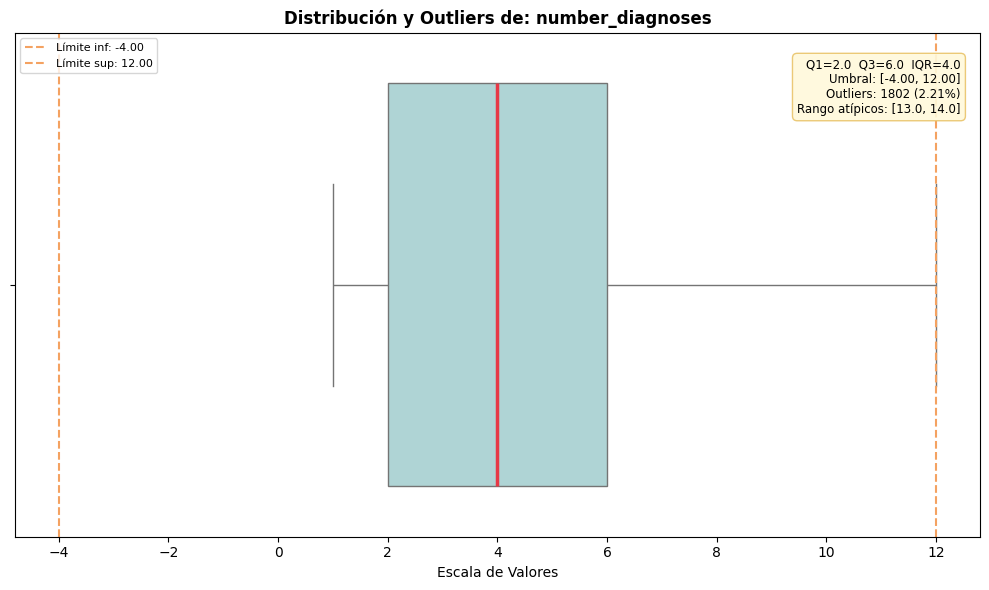

In [169]:
fig, ax = plt.subplots(figsize=(10,6))

serie_datos = IQR(y_train_strat)

sns.boxplot(
    x=serie_datos.filter_outliers(), 
    ax=ax, 
    color='#a8dadc',
    medianprops=dict(color='#e63946', linewidth=2.5),
    flierprops=dict(markerfacecolor='black', marker='o', alpha=0.5, markersize=4)
)

ax.set_title(f"Distribución y Outliers de: {col}", fontsize=12, fontweight='bold')
ax.set_xlabel("Escala de Valores")

# Líneas verticales de límites IQR
ax.axvline(serie_datos.lower, color='#f4a261', linewidth=1.5, linestyle='--', label=f'Límite inf: {serie_datos.lower:.2f}')
ax.axvline(serie_datos.upper, color='#f4a261', linewidth=1.5, linestyle='--', label=f'Límite sup: {serie_datos.upper:.2f}')

# Texto con estadísticas dentro del gráfico
stats_text = (
    f"Q1={serie_datos.filter_outliers().quantile(0.25):.1f}  Q3={serie_datos.filter_outliers().quantile(0.75):.1f}  IQR={serie_datos.range:.1f}\n"
    f"Umbral: [{serie_datos.lower:.2f}, {serie_datos.upper:.2f}]\n"
    f"Outliers: {len(serie_datos.get_outliers())} ({serie_datos.get_outliers_proportion()}%)"
)
if len(serie_datos.get_outliers()) > 0:
    stats_text += f"\nRango atípicos: [{serie_datos.get_outliers().min():.1f}, {serie_datos.get_outliers().max():.1f}]"

ax.text(
    0.98, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=8.5,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff9db', edgecolor='#e9c46a', alpha=0.9)
)

ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

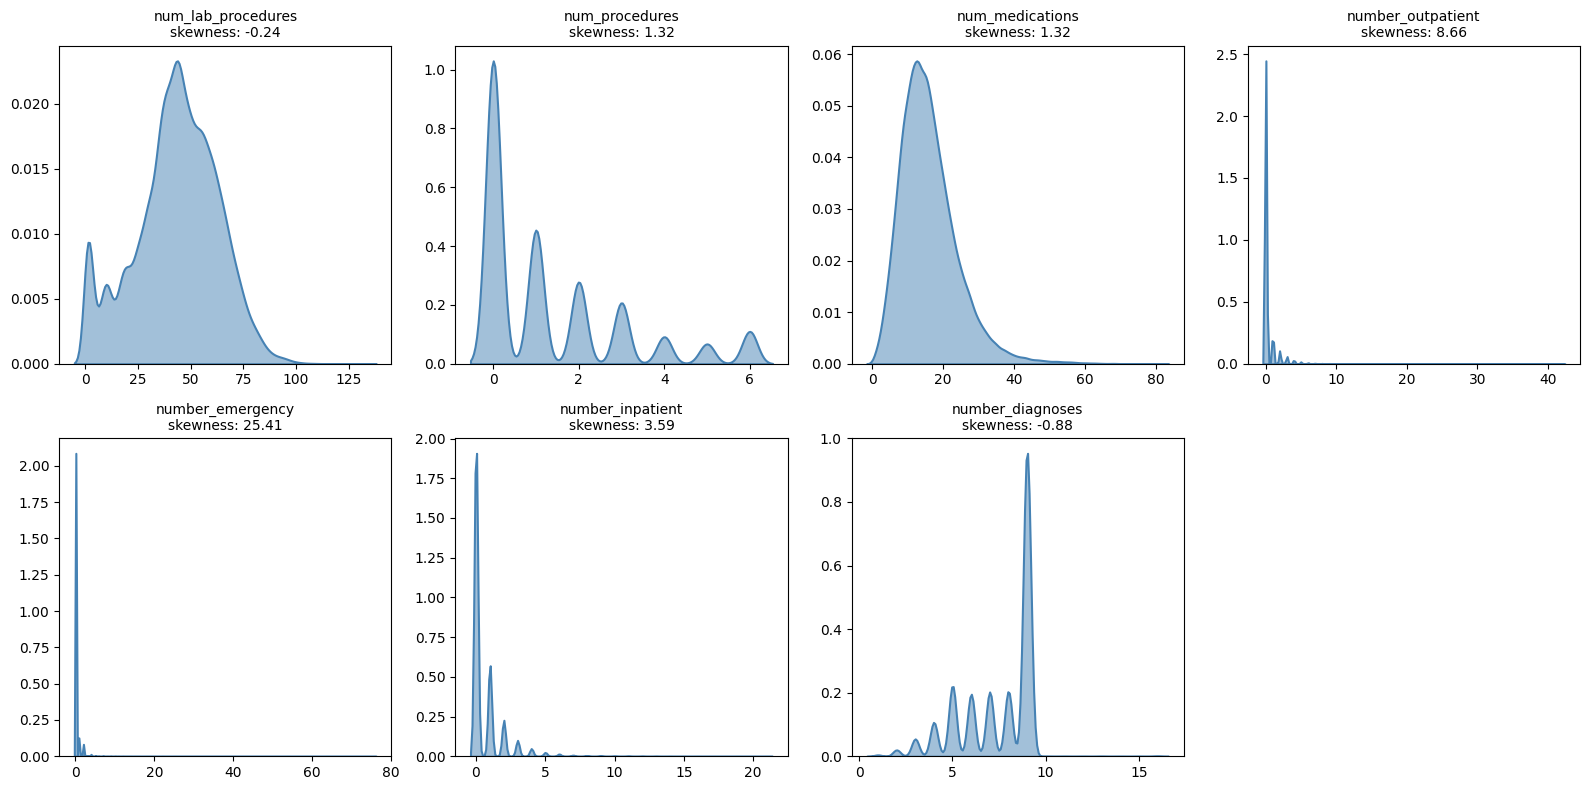

In [170]:
plot_skewness(columnas_numericas)

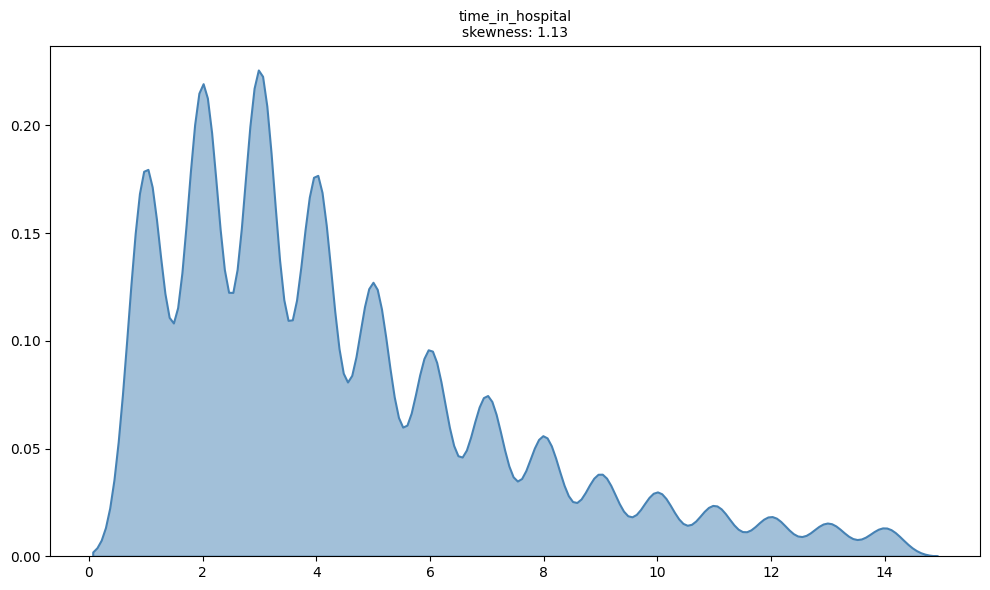

In [171]:
fig, ax = plt.subplots(figsize=(10,6))
skew = y_train_strat.skew()
        
sns.kdeplot(
    y_train_strat.dropna(),
    ax=ax,
    fill=True,
    color='steelblue',
    alpha=0.5,
    linewidth=1.5
)

ax.set_title(f'{y_train_strat.name}\nskewness: {skew:.2f}', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [172]:
X_train_strat.describe()

,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,81412.000000,81412.000000,81412.000000,81412.000000,81412.000000,81412.000000,81412.000000
mean,43.123913,1.339667,16.033988,0.368852,0.194099,0.635742,7.422677
std,19.642855,1.709067,8.117912,1.257310,0.903541,1.259624,1.934908
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,32.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [173]:
y_train_strat.describe().to_frame()

,time_in_hospital
count,81412.000000
mean,4.396010
std,2.985145
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,14.000000


### Conclusiones del Análisis de Outliers

- Los outliers, tanto de los features como de la target, oscilan entre el 0.22% y el 16%. Al eliminarlos, disminuyó la asimetría en la mayoria de las distribuciones
- Tanto `number_outpatient` como `number_emergency` tenían una abrumadora mayoría de ceros: 84% y 89% respectivamente. Es decir que la gran mayoría de los casos atendidos no tenían ni visitas ambulatorias ni de urgencia en el último año. Respecto a `number_inpatient`, hay un grupo significativo que tuvo una internación en el último año. Sin embargo, nos interesa conservar la información de si el paciente tuvo o no algún tipo de atención médica en el último año. Así que no se van a filtrar esas variables sino condensar en `in_out_emergency`
- La variable target no varió demasiado, pero se eliminaron los valores del extremo más alto. Se hará lo mismo con el resto de las variables

In [174]:
X_train_strat["in_out_emergency"] = X_train_strat[["number_outpatient","number_inpatient", "number_emergency"]].apply(lambda row: 1 if row.any() else 0 , axis=1)
X_train_strat["in_out_emergency"].value_counts(normalize=True)

in_out_emergency
0    0.548482
1    0.451518
Name: proportion, dtype: float64

In [175]:
for col in columnas_numericas:
    X_train_strat[col] = IQR(X_train_strat[col]).filter_outliers()
y_train_strat = IQR(y_train_strat).filter_outliers()

#Se eliminan las columnas de inpatient 
X_train_strat = X_train_strat.drop(["number_outpatient","number_inpatient", "number_emergency"],axis=1)

X_train_strat.info()


<class 'pandas.core.frame.DataFrame'>
Index: 81412 entries, 79043 to 91395
Data columns (total 49 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   encounter_id                       81412 non-null  string  
 1   patient_nbr                        81412 non-null  string  
 2   race                               81412 non-null  object  
 3   gender                             81412 non-null  object  
 4   age                                81412 non-null  object  
 5   admission_type_id                  81412 non-null  category
 6   discharge_disposition_id           81412 non-null  category
 7   admission_source_id                81412 non-null  category
 8   payer_code                         81412 non-null  object  
 9   medical_specialty                  81412 non-null  object  
 10  num_lab_procedures                 81233 non-null  float64 
 11  num_procedures                     77409 n

Hay que eliminar las filas que quedaron inconsistentes por el filtro de outliers

In [176]:
mask = X_train_strat.notna().all(axis=1)
X_train_strat = X_train_strat[mask]
y_train_strat = y_train_strat[mask]
X_train_strat.info()


<class 'pandas.core.frame.DataFrame'>
Index: 75772 entries, 79043 to 91395
Data columns (total 49 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   encounter_id                       75772 non-null  string  
 1   patient_nbr                        75772 non-null  string  
 2   race                               75772 non-null  object  
 3   gender                             75772 non-null  object  
 4   age                                75772 non-null  object  
 5   admission_type_id                  75772 non-null  category
 6   discharge_disposition_id           75772 non-null  category
 7   admission_source_id                75772 non-null  category
 8   payer_code                         75772 non-null  object  
 9   medical_specialty                  75772 non-null  object  
 10  num_lab_procedures                 75772 non-null  float64 
 11  num_procedures                     75772 n

---

## Análisis de correlación


### 1. Análisis de relación numéricas-numérica

Como vimos anteriormente, el dataset presenta las siguientes variables numéricas:
 * `num_lab_procedures`
 * `num_procedures`
 * `num_medications`
 * `in_out_emergency`

Aplicaremos los coeficientes de Pearson, Spearman y Kendall para ver cómo es su relación con respecto a la target.

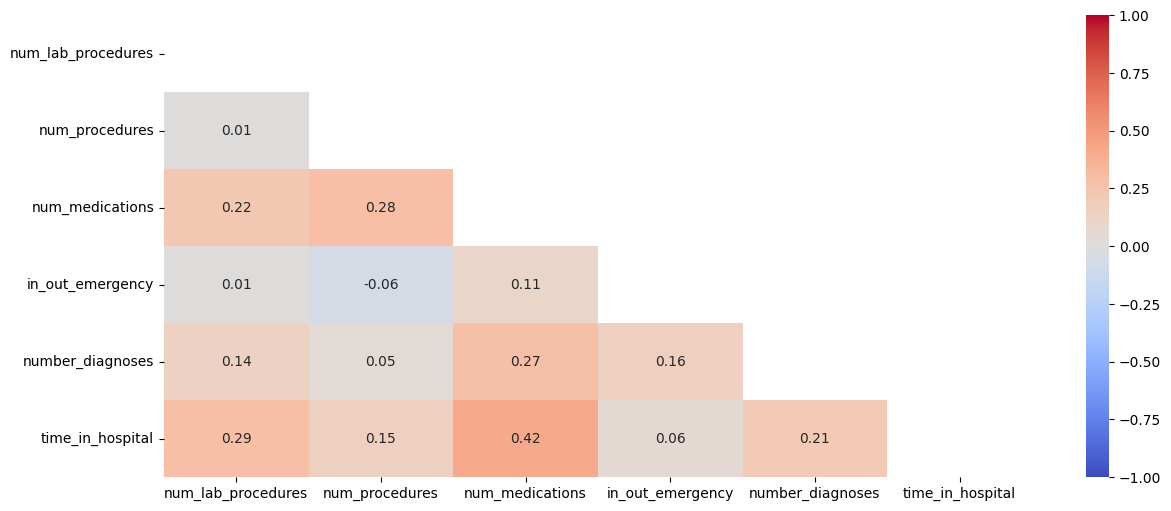

In [177]:
numericals = [
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "in_out_emergency",
    "number_diagnoses"
]
pearson = X_train_strat[numericals].join(y_train_strat).corr(method="pearson", numeric_only=False)
pearson_mask = np.triu(np.ones_like(pearson))

plt.figure(figsize=(14,6))
sns.heatmap(
    pearson, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1,
    mask=pearson_mask)


plt.show()


Vemos que, si bien `num_lab_procedures` y `num_medications` presentan un índice de correlación elevado, no es lo suficientemente fuerte como para identificar una relación lineal entre estas dos variables. Luego el resto, directamente, no tiene prácticamente relación con este índice.

Veamos por Spearman y Kendall.

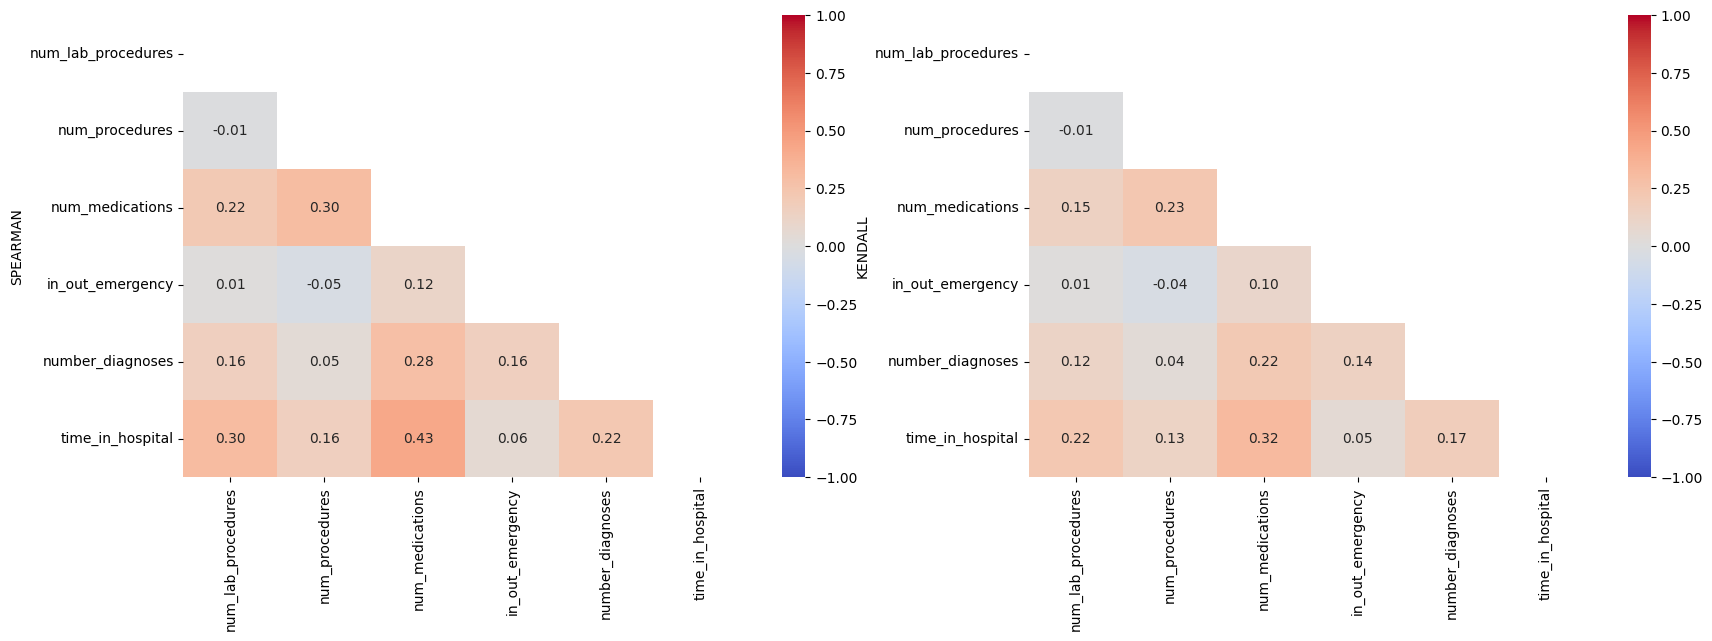

In [178]:
spearman = X_train_strat[numericals].join(y_train_strat).corr(method="spearman", numeric_only=False)
spearman_mask = np.triu(np.ones_like(spearman))

kendall = X_train_strat[numericals].join(y_train_strat).corr(method="kendall", numeric_only=False)
kendall_mask = np.triu(np.ones_like(kendall))

plt.figure(figsize=(20,6))
plt.subplot(1, 2, 1)

sns.heatmap(
    spearman, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1,
    mask=spearman_mask)
plt.ylabel('SPEARMAN')

plt.subplot(1, 2, 2)

sns.heatmap(
    kendall, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1,
    mask=kendall_mask)
plt.ylabel('KENDALL')

plt.show()


Por el lado de los coeficientes de Spearman y Kendall, vemos que las variables tampoco parecen presentar relaciones monótonas o no monótonas.

A priori podríamos pensar que la relación de la variable target para con las variables `num_lab_procedures` y num_medications tiende a ser lineal pero con fuerza moderada. Siendo `num_procedures` un poco más débil.

### 2. Análisis de relación categórica-numérica

Veremos primero la relación de la variable target con las variables categóricas nominales que no son medicamentos

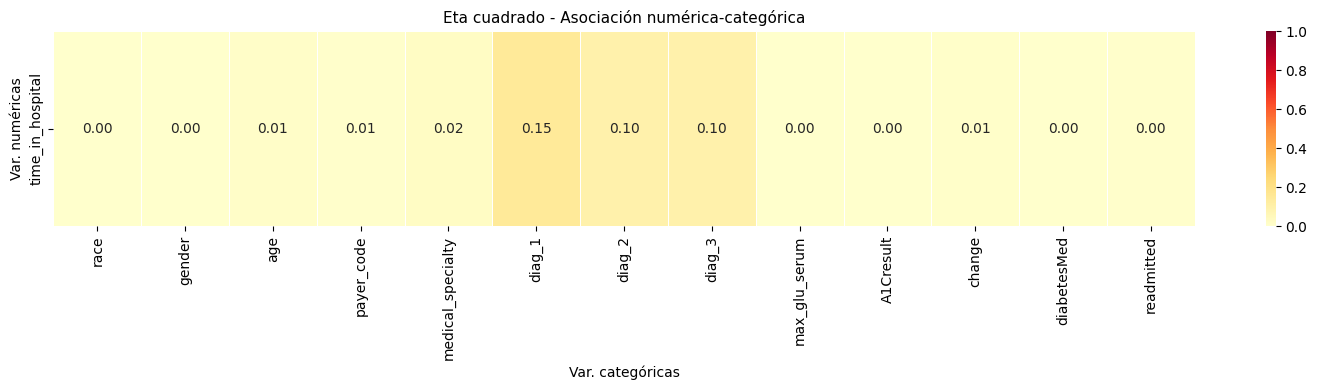

In [179]:
from utils.auxiliares import eta_squared

cat_cols = ['race', 'gender', 'age','payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult','change', 'diabetesMed', 'readmitted']

resultados = {}
for cat_col in cat_cols:
    eta2, p, F = eta_squared(y_train_strat, X_train_strat[cat_col])
    resultados[("time_in_hospital", cat_col)] = eta2

eta2_mat = pd.DataFrame(
    {cat: {"time_in_hospital": resultados[("time_in_hospital", cat)]} for cat in cat_cols}
)
# Dibujamos el heatmap
fig, ax = plt.subplots(figsize=(15, 4))
sns.heatmap(eta2_mat, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)

ax.set_title("Eta cuadrado - Asociación numérica-categórica", fontsize=11)
ax.set_xlabel("Var. categóricas")
ax.set_ylabel("Var. numéricas")
plt.tight_layout()
plt.show()

Si ahora analizamos medicamentos (se retiran Examide y Citoglipton dado que solo contienen dos valores únicos, podrían considerarse binarias).

In [180]:
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

# resultados = {}
# for cat_col in med_cols:
#     #Esto falla en glipizide
#     eta2, p, F = eta_squared(y_train_strat, X_train_strat[cat_col])
#     resultados[("time_in_hospital", cat_col)] = eta2

# eta2_mat = pd.DataFrame(
#     {cat: {"time_in_hospital": resultados[("time_in_hospital", cat)]} for cat in med_cols}
# )
# # Dibujamos el heatmap
# fig, ax = plt.subplots(figsize=(15, 4))
# sns.heatmap(eta2_mat, annot=True, fmt=".2f", cmap="YlOrRd",
#             vmin=0, vmax=1, linewidths=0.5, ax=ax)

# ax.set_title("Eta cuadrado - Asociación numérica-categórica", fontsize=11)
# ax.set_xlabel("Var. categóricas")
# ax.set_ylabel("Var. numéricas")
# plt.tight_layout()
# plt.show()

Podemos observar que ningún medicamento, salvo levemente la insulina, presenta algún tipo de relación con el tiempo que permanece un paciente en el hospital.

Si intentamos hacer un análisis de punto biserial para Examide y Citopligton, antes vamos a ver que:

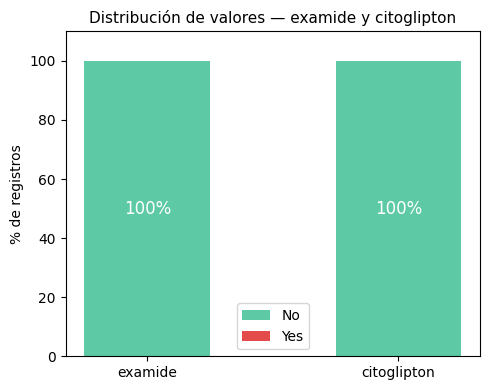

In [181]:
import matplotlib.pyplot as plt
import numpy as np

cols = ['examide', 'citoglipton']
no_pct  = [100, 100]
yes_pct = [0, 0]

x = np.arange(len(cols))
width = 0.5

fig, ax = plt.subplots(figsize=(5, 4))

bars_no  = ax.bar(x, no_pct,  width, label='No',  color='#5DCAA5')
bars_yes = ax.bar(x, yes_pct, width, bottom=no_pct, label='Yes', color='#E24B4A')

ax.set_xticks(x)
ax.set_xticklabels(cols)
ax.set_ylabel('% de registros')
ax.set_ylim(0, 110)
ax.set_title('Distribución de valores — examide y citoglipton', fontsize=11)
ax.legend()

for bar in bars_no:
    ax.text(bar.get_x() + bar.get_width()/2, 50,
            '100%', ha='center', va='center', color='white', fontsize=12)

plt.tight_layout()
plt.show()

Estas dos variables tienen valores completamente nulos, por lo que no podemos aplicar un punto biserial. Examide y citoglipton no aportan variabilidad y pueden descartarse.

### 3. Conclusiones

A partir del análisis de correlación realizado, es posible identificar que la mayoría de las variables presentan una asociación débil con `time_in_hospital`.

Entre las variables numéricas, `num_lab_procedures` y `num_medications` exhiben la correlación más elevada con el target, aunque sin alcanzar un umbral que permita hablar de relación lineal fuerte.

En el caso de las variables categóricas de medicación, la insulina muestra el mayor efecto sobre el target según el coeficiente η², si bien su magnitud continúa siendo moderada.

Por otro lado, las variables de diagnóstico (`diag_1`, `diag_2` y `diag_3`) se destacan notoriamente del resto, presentando los valores de η² más elevados del análisis. Esto sugiere que **el tipo de diagnóstico registrado durante la internación es el factor con mayor influencia sobre la duración de la estadía hospitalaria**.

Finalmente, cabe señalar que las variables Examide y Citoglipton fueron excluidas del análisis de punto biserial por presentar varianza nula — la totalidad de sus registros corresponde al valor `No` —, lo que las hace estadísticamente no informativas como predictores.

---

## Selección de features


Aplicaremos la evaluación por información mutua, valiéndonos de las matrices de correlación vistas anteriormente.

In [ ]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

# mi_num = mutual_info_regression(X_train_strat[numericals], y_train_strat, discrete_features=False, random_state=42)
# mi_series = pd.Series(mi_num, index=numericals, name='MI')

# concat_cols = cat_cols + med_cols

# oe = OrdinalEncoder()
# X_train_strat_encoded = oe.fit_transform(X_train_strat[concat_cols].astype(str))

# mi_cat = mutual_info_classif(X_train_strat_encoded, y_train_strat, discrete_features=True, random_state=42)
# mi_cat_series = pd.Series(mi_cat, index=concat_cols, name='MI')

# mi_all = pd.concat([mi_series, mi_cat_series])

# mi_result = pd.DataFrame({
#     'score': mi_all
# }).sort_values('score', ascending=False)

# print(mi_result.head(10))


Si vemos los 10 scores más altos, podemos confirmar el análisis previo: las tres variables de diagnóstico tienen mayor poder predictivo sobre la target, luego `num_medications` también tiene bastante poder predictivo a pesar de la poca fuerza de relación que presenta y `num_lab_procedures` no tiene un score tan alto (acorde a la relación débil que habíamos mencionado).

Para terminar de cerrar la idea sobre las tres variables categóricas, aplicaremos un último análisis utilizando la medida de asosiación de Cramer's V.

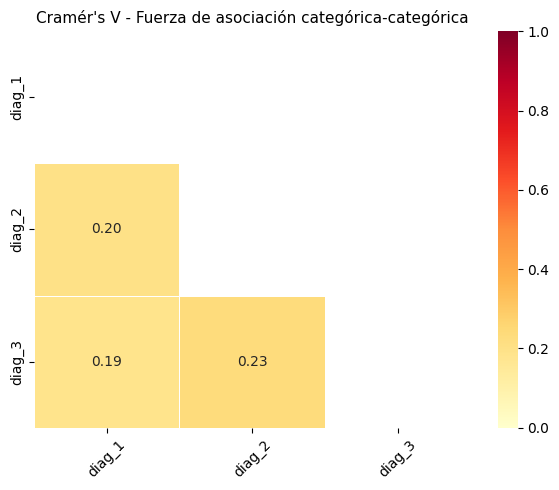

In [183]:
from utils.auxiliares import cramers_v

diag_cols = ['diag_1', 'diag_2', 'diag_3']

v_mat = pd.DataFrame(index=diag_cols, columns=diag_cols, dtype=float)

for c1 in diag_cols:
    for c2 in diag_cols:
        if c1 == c2:
            v_mat.loc[c1, c2] = 1.0
        else:
            mask = X_train_strat[c1].notna() & X_train_strat[c2].notna()
            v_mat.loc[c1, c2] = cramers_v(
                X_train_strat.loc[mask, c1], X_train_strat.loc[mask, c2]
            )


mask = np.triu(np.ones_like(v_mat, dtype=bool))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(v_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5,
            mask=mask, ax=ax)

ax.set_title("Cramér's V - Fuerza de asociación categórica-categórica", fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Podemos observar que las tres variables presentan una medida de asociación moderada, podríamos interpretar que cada una está capturando un aspecto diferente sobre el diagnóstico final que influye en los días que un paciente permanece en el hospital.

Una alternativa podría ser aplicar PCA, pero dado que tenemos muchas variables categóricas, no conviene aplicar este método porque implicaría hacer un encoding para cada variable, lo que haría crecer demasiado la dimensionalidad del dataset.